<h2 style="color:blue" align="center">Handwritten digits classification using KNN</h2>

In [ ]:
#pip install tensorflow

In [38]:
from tensorflow import keras
from tensorflow.keras import datasets
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [39]:
(X_train, y_train) , (X_test, y_test) = datasets.mnist.load_data()

In [40]:
len(X_train)

60000

In [4]:
X_train.shape

(60000, 28, 28)

In [41]:
len(X_test)

10000

In [42]:
type(X_train)

numpy.ndarray

In [43]:
X_train[0].shape

(28, 28)

In [44]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  30,  36,  94, 154, 170,
        253, 253, 253, 253, 253, 225, 172, 253, 242, 195,  64,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  49, 238, 253, 253, 253, 253,
        253, 253, 253, 253, 251,  93,  82,  82,  56,  39,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  18, 219, 253, 253, 253, 253,
        253, 198, 182, 247, 241,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  80, 156, 107, 253, 253,
        205,  11,   0,  43, 154,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  14,   1, 154, 253,
         90,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 139, 253,
        190,   2,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  11, 190,
        253,  70,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  35,
        241, 225, 160, 108,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         81, 240, 253, 253, 119,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  45, 186, 253, 253, 150,  27,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  16,  93, 252, 253, 187,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0, 249, 253, 249,  64,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  46, 130, 183, 253, 253, 207,   2,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  39,
        148, 229, 253, 253, 253, 250, 182,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  24, 114, 221,
        253, 253, 253, 253, 201,  78,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  23,  66, 213, 253, 253,
        253, 253, 198,  81,   2,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,  18, 171, 219, 253, 253, 253, 253,
        195,  80,   9,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,  55, 172, 226, 253, 253, 253, 253, 244, 133,
         11,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0, 136, 253, 25

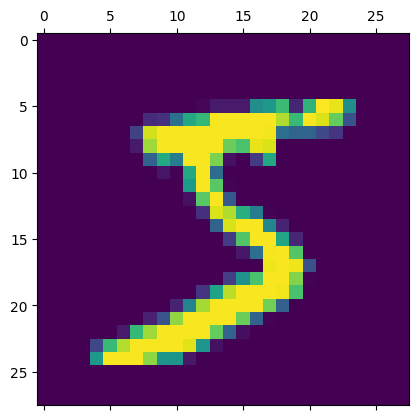

In [45]:
plt.matshow(X_train[0])

In [46]:
y_train[0]

np.uint8(5)

In [47]:
X_train = X_train / 255
X_test = X_test / 255

In [48]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

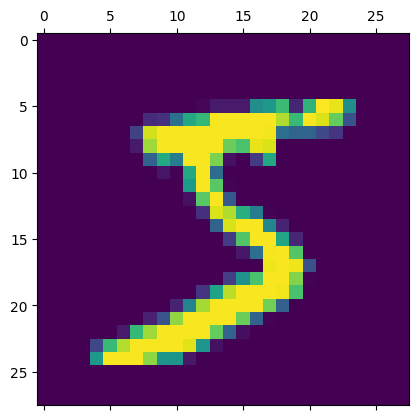

In [49]:
plt.matshow(X_train[0])

In [50]:
X_train_flattened = X_train.reshape(len(X_train), 28*28)   #60000, 784
X_test_flattened = X_test.reshape(len(X_test), 28*28)

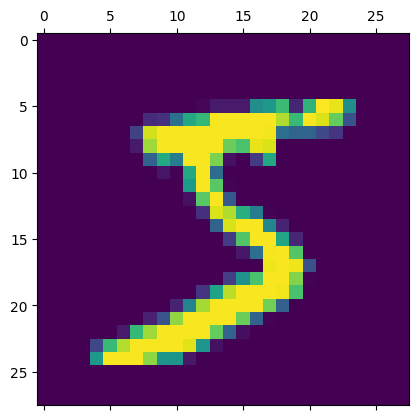

In [51]:
plt.matshow(X_train_flattened[0].reshape(28,28))

In [52]:
X_train_flattened[0]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [53]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_flattened, y_train)

KNeighborsClassifier(n_neighbors=3)

In [54]:
knn.score(X_test_flattened, y_test)

0.9705

In [55]:
knn.predict(X_test_flattened)

array([7, 2, 1, ..., 4, 5, 6], dtype=uint8)

<h3 style='color:purple'>Very simple neural network with no hidden layers</h3>

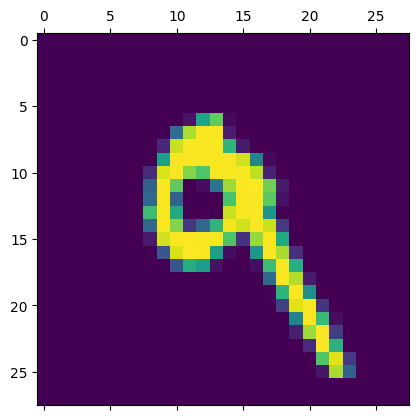

In [56]:
#y_test[6] #X_test[11]

plt.matshow(X_test[7])

In [58]:
X_test_flattened[7]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

In [59]:
import pandas as pd
df = pd.DataFrame(X_test_flattened[7])
df = df.T
df

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [60]:
knn.predict(df)

array([9], dtype=uint8)

### Roted

In [61]:
import cv2

In [62]:
X_test[6]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [63]:
X_test[6].shape

(28, 28)

In [64]:
h, w = X_test[6].shape[:2]

center = (w / 2, h / 2)
mat = cv2.getRotationMatrix2D(center, 90, 1)
rotimg = cv2.warpAffine(X_test[6], mat, (h, w))

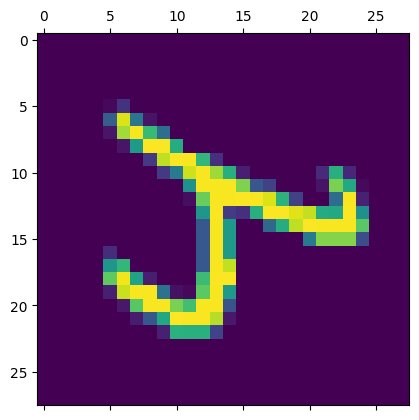

In [65]:
plt.matshow(rotimg)

In [66]:
rotimg.shape

(28, 28)

In [67]:
rotimg = rotimg.reshape(1, 28*28)

In [68]:
df = pd.DataFrame(rotimg)
df

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [69]:
knn.predict(df)

array([5], dtype=uint8)

### For Hard disk Image

In [76]:
from google.colab import files
files.upload()

Saving modified.png to modified.png


{'modified.png': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01\xa3\x00\x00\x01\xa4\x08\x06\x00\x00\x00\x9c\x90JL\x00\x00\x00:tEXtSoftware\x00Matplotlib version3.10.0, https://matplotlib.org/\x94rXr\x00\x00\x00\tpHYs\x00\x00\x0fa\x00\x00\x0fa\x01\xa8?\xa7i\x00\x00\x1c\x94IDATx\x9c\xed\xdd}pTu\xbe\xe7\xf1O\xf3\x90\x064\xe9\x18b\xd2\x89\x04\x08\xa8\xe0\xc8\x83%J&\x17ep\xc8\x02\x99{)@v\n\x1f\xa6\x16,\x16\x16\x0c\x96\xc08Z\x99U\xd0y\xb8\x99a\xb6\x18G\x97\x91{\xb7f\x88\xee\n:\xd6\n\x94\xee\x0cs1\x90\xb0\x8c\t\x16\x08\x97\xcb\xa8)Be$\\HP\xee\xa5;\x04i\x02\xf9\xed\x1f,\xcd\xb4\x04\xf0\xb4\xdd\xf9&\xcd\xfbUu\xca\xf49\xe7\xdb\xe7\xeb\xcf#\x1fN\x9f\x93_\xfb\x9csN\x00\x00\x18\xeae\xdd\x00\x00\x00\x84\x11\x00\xc0\x1ca\x04\x000G\x18\x01\x00\xcc\x11F\x00\x00s\x84\x11\x00\xc0\x1ca\x04\x000G\x18\x01\x00\xcc\x11F\x00\x00s\x84\x11\x00\xc0\\\x8f\t\xa35k\xd6h\xe8\xd0\xa1\xea\xd7\xaf\x9f\x8a\x8a\x8a\xf4\xc1\x07\x1fX\xb7\xd4\xe5\x9e\x7f\xfey\xf9|\xbe\x98e\xe4\xc8\x91\xd6mu\x89\x1d;vh\xfa\xf4\xe9\xca\xcf\

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)
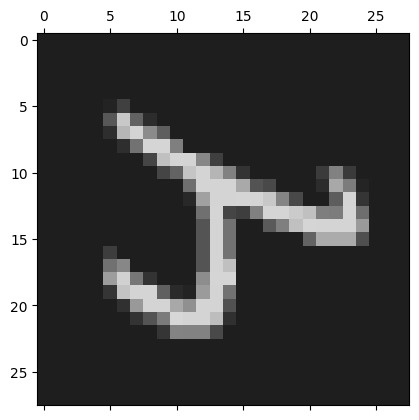

In [77]:
modified_image = cv2.imread('modified.png', cv2.IMREAD_GRAYSCALE)
modified_image

In [78]:
modified_image.shape

(420, 419)

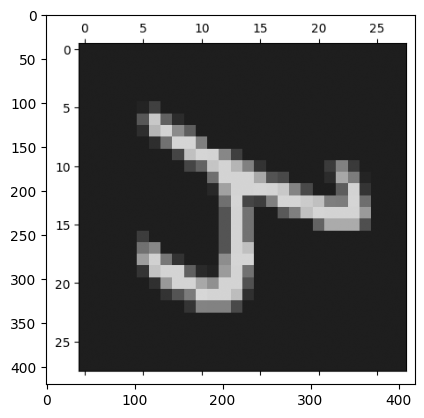

In [79]:
plt.imshow(modified_image, cmap='gray')

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)
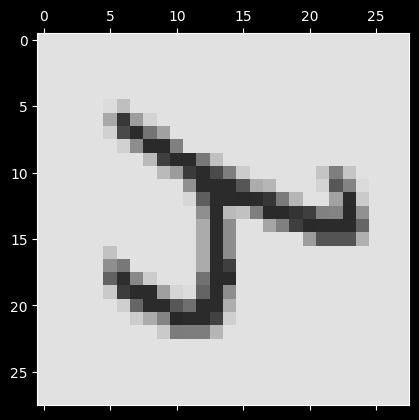

In [80]:
img_resizedM = cv2.bitwise_not(modified_image)
img_resizedM

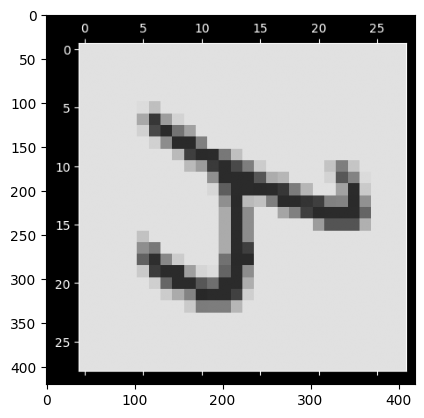

In [81]:
plt.imshow(img_resizedM, cmap='gray')

In [82]:
img_resizedM = cv2.resize(img_resizedM, (28, 28), interpolation=cv2.INTER_LINEAR)
img_resizedM

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0, 240, 233, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225,   0],
       [  0,   0, 233, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225,   0],
       [  0,   0, 233, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225,   0],
       [  0,   0, 233, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225,   0],
       [  0,   0, 233, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225,   0],
       [  0,   0, 233, 225, 225, 225, 225, 220, 191, 225, 225, 225, 225,
        225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225,   0],
       [  0,   0, 233, 225, 225, 225, 225, 209,  73,  43, 144, 225, 225,
        225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225,   0],
       [  0,   0, 233, 225, 225, 225, 225, 225, 209, 141,  42, 128, 225,
        225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225,   0],
       [  0,   0, 233, 225, 225, 225, 225, 225, 225, 225, 109,  42,  43,
        120, 192, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225,   0],
       [  0,   3, 235, 225, 225, 225, 225, 225, 225, 225, 201, 156,  58,
         43,  74, 126, 204, 225, 225, 225, 225, 196, 126, 197, 225, 225,
        225,   0],
       [  0,   0, 233, 225, 225, 225, 225, 225, 225, 225, 225, 225, 144,
         43,  43,  43,  86, 172, 225, 225, 225, 211,  87, 131, 219, 225,
        225,   0],
       [  0,   0, 233, 225, 225, 225, 225, 225, 225, 225, 225, 225, 215,
         94,  43,  43,  42,  43, 123, 182, 225, 225, 162,  43, 202, 225,
        225,   0],
       [  0,   0, 233, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        143,  42, 186, 193, 127,  42,  52,  63, 129, 131,  42, 145, 225,
        225,   0],
       [  0,   0, 233, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        171,  43, 141, 225, 225, 225, 225, 156,  84,  84,  84, 176, 225,
        225,   0],
       [  0,   0, 233, 225, 225, 225, 225, 194, 225, 225, 225, 225, 225,
        171,  43, 141, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225,   0],
       [  0,   0, 233, 225, 225, 225, 225, 142, 120, 225, 225, 225, 225,
        171,  43,  63, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225,   0],
       [  0,   0, 233, 225, 225, 225, 225,  98,  46, 136, 217, 225, 225,
        114,  42,  42, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225,   0],
       [  0,   0, 233, 225, 225, 225, 225, 202,  60,  43, 116, 213, 220,
        100,  43, 141, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225,   0],
       [  0,   0, 233, 225, 225, 225, 225, 225, 207, 102,  43,  87, 111,
         43,  43, 174, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225,   0],
       [  0,   0, 233, 225, 225, 225, 225, 225, 225, 204, 147,  40,  43,
         43,  66, 207, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225,   0],
       [  0,   0, 233, 225, 225, 225, 225, 225, 225, 225, 211, 124, 125,
        125, 182, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225,   0],
       [  0,   0, 233, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225, 225,
        225,   0],
       [  0,   0, 233, 225, 225, 225, 22

In [83]:
img_resizedM.shape

(28, 28)

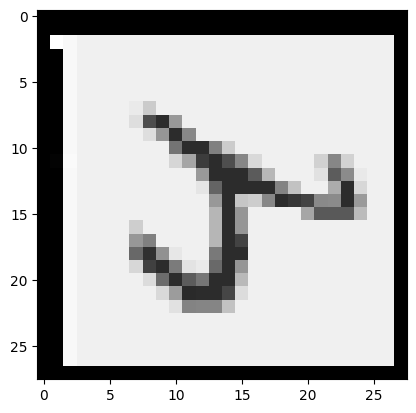

In [84]:
plt.imshow(img_resizedM, cmap='gray')

In [85]:
img_resizedM=img_resizedM/255
img_resizedM

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.94117647, 0.91372549, 0.88235294, 0.88235294,
        0.88235294, 0.88235294, 0.88235294, 0.88235294, 0.88235294,
        0.88235294, 0.88235294, 0.88235294, 0.88235294, 0.88235294,
        0.88235294, 0.8823

In [86]:
img_resizedM_Flat = img_resizedM.reshape(1, 28*28)
img_resizedM_Flat

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.94117647, 0.91372549, 0.88235294,
        0.88235294, 0.88235294, 0.88235294, 0.88235294, 0.88235294,
        0.88235294, 0.88235294, 0.88235294, 0.88235294, 0.88235294,
        0.88235294, 0.88235294, 0.88235294, 0.88

In [87]:
df = pd.DataFrame(img_resizedM_Flat)
df = df
df

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [88]:
knn.predict(df)

array([0], dtype=uint8)

In [89]:
import joblib as jbl

jbl.dump(knn,'KNNModel_Job')

['KNNModel_Job']

In [90]:
from google.colab import files
files.download('KNNModel_Job')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>